# Module 1: Data Analysis and Preprocessing
This notebook performs initial dataset analysis, text cleaning, and various tokenization methods (including BPE and morphological via `stanza`).

In [1]:
!pip install -q stanza nltk scikit-learn transformers sentencepiece matplotlib seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\shola\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import json
import re
import string
import os
import stanza
import nltk
import numpy as np
from nltk.tokenize import word_tokenize, sent_tokenize
from sklearn.model_selection import train_test_split
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

nltk.download('punkt')
nltk.download('punkt_tab')
# stanza.download('kk')
# nlp = stanza.Pipeline('kk')

from transformers import AutoTokenizer
bpe_tokenizer = AutoTokenizer.from_pretrained('google/mt5-small')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\shola\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\shola\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


C:\Users\shola\Downloads\ML\.venv\Lib\site-packages\transformers\convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


## 1. Load Data and Basic Statistics

Сводная таблица статистик (ТЗ, раздел 1):


,Показатель,Значение
0,Число документов,45.00
1,"Токенов (NLTK word_tokenize, нижний регистр)",20748.00
2,Уникальных слов (типы),5914.00
3,"Средняя длина текста, слов (по пробелам)",366.02
4,"Средняя длина текста, токенов (NLTK)",461.07
5,"Средняя длина предложения, слов (по пробелам)",13.95


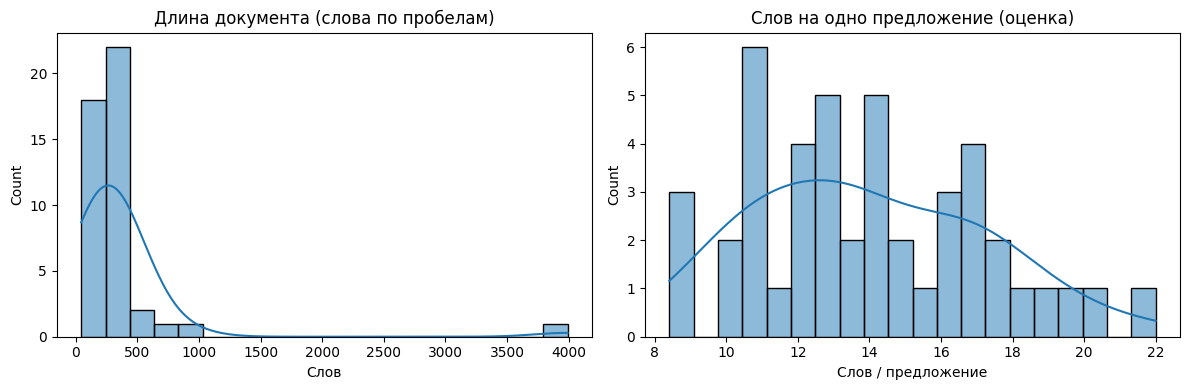

In [3]:
path = 'abai-sozderi.json'
if not os.path.isfile(path):
    raise FileNotFoundError(f'Нет файла {path}. Положите корпус в корень проекта.')

with open(path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)

def _sent_count(t):
    return max(1, len(sent_tokenize(str(t))))

df['char_length'] = df['text'].apply(lambda x: len(str(x)))
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['sentence_count'] = df['text'].apply(_sent_count)
df['token_nltk'] = df['text'].apply(lambda x: len(word_tokenize(str(x).lower())))

all_wt = []
for t in df['text']:
    all_wt.extend(word_tokenize(str(t).lower()))
n_docs = len(df)
n_tokens = len(all_wt)
n_types = len(set(all_wt))

summary = pd.DataFrame({
    'Показатель': [
        'Число документов',
        'Токенов (NLTK word_tokenize, нижний регистр)',
        'Уникальных слов (типы)',
        'Средняя длина текста, слов (по пробелам)',
        'Средняя длина текста, токенов (NLTK)',
        'Средняя длина предложения, слов (по пробелам)',
    ],
    'Значение': [
        n_docs,
        n_tokens,
        n_types,
        round(df['word_count'].mean(), 2),
        round(df['token_nltk'].mean(), 2),
        round((df['word_count'] / df['sentence_count']).mean(), 2),
    ],
})
print('Сводная таблица статистик (ТЗ, раздел 1):')
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['word_count'], bins=20, kde=True, ax=axes[0])
axes[0].set_title('Длина документа (слова по пробелам)')
axes[0].set_xlabel('Слов')
sns.histplot(df['word_count'] / df['sentence_count'], bins=20, kde=True, ax=axes[1])
axes[1].set_title('Слов на одно предложение (оценка)')
axes[1].set_xlabel('Слов / предложение')
plt.tight_layout()
plt.show()

## 2. Train / Validation / Test Split

In [4]:
# Split using 80/10/10 ratio
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train set size: {len(train_df)}")
print(f"Validation set size: {len(val_df)}")
print(f"Test set size: {len(test_df)}")

train_df.to_csv('data/train.csv', index=False)
val_df.to_csv('data/val.csv', index=False)
test_df.to_csv('data/test.csv', index=False)

Train set size: 36
Validation set size: 4
Test set size: 5


## 3. Режимы предобработки и их сравнение
Три основных варианта по ТЗ + влияние стоп-слов; морфология через Stanza (если доступна `kk`).

In [5]:
# Stanza для казахского; при сбое морфологический режим отключается
nlp = None
try:
    nlp = stanza.Pipeline('kk', processors='tokenize,mwt,pos,lemma', verbose=False)
except Exception:
    try:
        stanza.download('kk', verbose=False)
        nlp = stanza.Pipeline('kk', processors='tokenize,mwt,pos,lemma', verbose=False)
    except Exception as e:
        print('Stanza kk недоступна, морфологический режим пропущен:', e)

# Короткий список стоп-слов для демонстрации влияния (при необходимости расширьте)
KZ_STOP = set('''және не үшін да де ма ме мен бұл ол бір сонда әлі өте қандай
көр мын сияқты болар еді гана дағы'''.split())


def preprocess_basic(text):
    """punctuation removal + lowercase + tokenization (NLTK)."""
    text = str(text).lower()
    text = text.translate(str.maketrans('', '', string.punctuation + '«»—–'))
    return word_tokenize(text)


def preprocess_basic_nostop(text):
    return [w for w in preprocess_basic(text) if w not in KZ_STOP]


def preprocess_morphological(text):
    if nlp is None:
        return preprocess_basic(text)
    doc = nlp(str(text))
    tokens = []
    for sent in doc.sentences:
        for word in sent.words:
            lem = (word.lemma or '').lower()
            if lem and lem.replace(' ', '').isalpha():
                tokens.append(lem)
    return tokens


def preprocess_bpe(text):
    return bpe_tokenizer.tokenize(str(text))


def sentence_segments(text):
    return [s.strip() for s in sent_tokenize(str(text)) if s.strip()]


def token_chunks(tokens, size=80, overlap=20):
    """Chunking с перекрытием по списку токенов."""
    step = max(1, size - overlap)
    if len(tokens) <= size:
        return [tokens]
    chunks = []
    i = 0
    while i + size <= len(tokens):
        chunks.append(tokens[i:i + size])
        i += step
    if not chunks or chunks[-1] != tokens[-size:]:
        chunks.append(tokens[-size:])
    return chunks

In [6]:
sample_text = df['text'].iloc[0]
print('Фрагмент исходного текста:\n', sample_text[:200], '...\n')


def _summarize_rows(name, docs_tokens):
    flat = [t for doc in docs_tokens for t in doc]
    u = len(set(map(str, flat)))
    n = len(flat)
    return {'режим': name, 'токенов': n, 'уникальных_типов': u, 'TTR': round(u / max(n, 1), 4)}

rows_cmp = []
rows_cmp.append(_summarize_rows('1 punct+lower+NLTK', [preprocess_basic(t) for t in df['text']]))
rows_cmp.append(_summarize_rows('2 без стоп-слов', [preprocess_basic_nostop(t) for t in df['text']]))
rows_cmp.append(_summarize_rows('3 BPE / SentencePiece (mT5)', [preprocess_bpe(t) for t in df['text']]))
if nlp is not None:
    rows_cmp.append(_summarize_rows('4 морфология + леммы (Stanza)', [preprocess_morphological(t) for t in df['text']]))

cmp_df = pd.DataFrame(rows_cmp)
print('Сравнение режимов предобработки (весь корпус):')
display(cmp_df)

basic_sample = preprocess_basic(sample_text)
seg = sentence_segments(sample_text)
ch = token_chunks(basic_sample, size=50, overlap=15)
print(f'Сегментация: предложений в первом документе — {len(seg)}')
print(f'Chunking (50 токенов, overlap 15): число чанков — {len(ch)}')
print('\n--- Пример токенов ---')
print('Basic:', basic_sample[:30], '...')
print('BPE:', preprocess_bpe(sample_text)[:30], '...')
if nlp is not None:
    print('Morph:', preprocess_morphological(sample_text)[:30], '...')

print(
    '\nСтемминг: для казахского в NLTK нет готового стеммера; '
    'в отчёте укажите, что лемматизация (Stanza) играет роль, близкую к «нормализации» морфем.'
)

Фрагмент исходного текста:
 Бұл жасқа келгенше жақсы өткіздік пе, жаман өткіздік пе, әйтеуір бірталай өмірімізді өткіздік: алыстық, жұлыстық, айтыстық, тартыстық - әурешілікті көре-көре келдік. Енді жер ортасы жасқа келдік: қажы ...



Сравнение режимов предобработки (весь корпус):


,режим,токенов,уникальных_типов,TTR
0,1 punct+lower+NLTK,16110,5894,0.3659
1,2 без стоп-слов,14883,5877,0.3949
2,3 BPE / SentencePiece (mT5),40492,2803,0.0692
3,4 морфология + леммы (Stanza),15992,2970,0.1857


Сегментация: предложений в первом документе — 25
Chunking (50 токенов, overlap 15): число чанков — 8

--- Пример токенов ---
Basic: ['бұл', 'жасқа', 'келгенше', 'жақсы', 'өткіздік', 'пе', 'жаман', 'өткіздік', 'пе', 'әйтеуір', 'бірталай', 'өмірімізді', 'өткіздік', 'алыстық', 'жұлыстық', 'айтыстық', 'тартыстық', 'әурешілікті', 'көрекөре', 'келдік', 'енді', 'жер', 'ортасы', 'жасқа', 'келдік', 'қажыдық', 'жалықтық', 'қылып', 'жүрген', 'ісіміздің'] ...
BPE: ['▁', 'Бұл', '▁жас', 'қа', '▁келген', 'ше', '▁жақ', 'сы', '▁өткіз', 'дік', '▁пе', ',', '▁жам', 'ан', '▁өткіз', 'дік', '▁пе', ',', '▁әйт', 'еуі', 'р', '▁бір', 'та', 'лай', '▁', 'өмір', 'імізді', '▁өткіз', 'дік', ':'] ...


Morph: ['бұл', 'жас', 'кел', 'жақсы', 'өткіз', 'ма', 'жаман', 'өткіз', 'ма', 'әйтеуір', 'бірталай', 'өмір', 'өткіз', 'алыстық', 'жұлыстық', 'айтыстық', 'тартыстық', 'әурешілік', 'кел', 'енді', 'жер', 'орта', 'жас', 'кел', 'қажыдық', 'жалықтық', 'қыл', 'жүр', 'іс', 'баянсыз'] ...

Стемминг: для казахского в NLTK нет готового стеммера; в отчёте укажите, что лемматизация (Stanza) играет роль, близкую к «нормализации» морфем.


## 4. Частотный анализ, n-граммы, темы, богатство словаря

Most frequent words:
 [('деп', 192), ('бір', 191), ('да', 179), ('де', 155), ('жоқ', 140), ('ол', 140), ('не', 123), ('болса', 123), ('бар', 113), ('екен', 111)]

Most frequent bigrams:
 [(('құдай', 'тағала'), 21), (('емес', 'пе'), 18), (('болса', 'да'), 16), (('оның', 'үшін'), 16), (('жоқ', 'болса'), 15), (('өзі', 'де'), 15), (('алла', 'тағаланың'), 15), (('екен', 'деп'), 13), (('онан', 'соң'), 13), (('адам', 'баласының'), 13)]



Topics (Topic Modeling):
Topic 1:  ол, бұл, болады, де, емес, да, бар, болса, деп, адам
Topic 2:  болады, де, адам, үшін, бар, керек, сол, да, өзі, адамның
Topic 3:  деп, да, жоқ, де, не, мал, болса, осы, керек, кісі
Topic 4:  деп, екен, да, де, болса, жоқ, ол, бар, не, екі
Topic 5:  керек, не, адам, ол, бар, еді, дейді, болмаса, деп, емес

Most frequent trigrams:
 [(('болар', 'ма', 'екен'), 4), (('еңбек', 'қылып', 'мал'), 3), (('болса', 'екен', 'деп'), 3), (('мүмкін', 'де', 'емес'), 3), (('осы', 'екеуі', 'маған'), 3), (('екеуі', 'маған', 'қалай'), 3), (('маған', 'қалай', 'таласады'), 3), (('аз', 'ба', 'көп'), 3), (('ба', 'көп', 'пе'), 3), (('оған', 'құдай', 'тағала'), 3)]

TTR по документам: mean=0.7440, std=0.0778


Средняя длина предложения (токены NLTK): 16.62


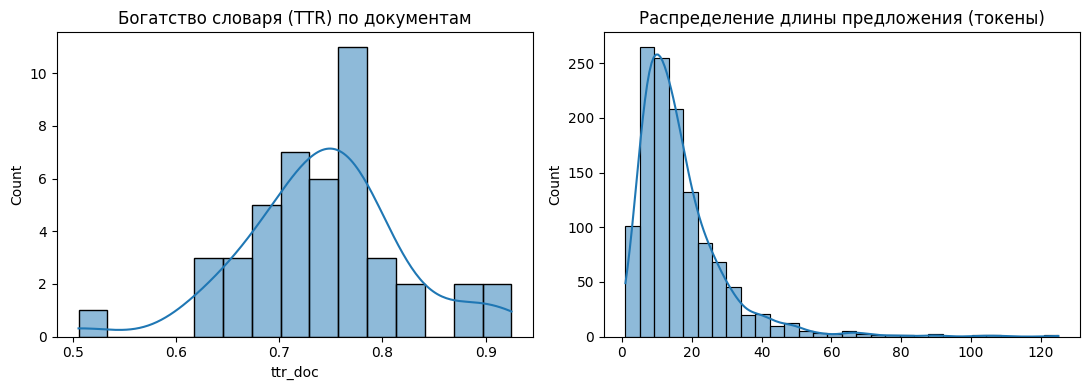

In [7]:
from nltk.util import ngrams
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

all_basic_tokens = []
for t in df['text']:
    all_basic_tokens.extend(preprocess_basic(t))
    
# Word frequencies
word_freq = Counter(all_basic_tokens)
print("Most frequent words:\n", word_freq.most_common(10))

# Bigrams
bigram_freq = Counter(ngrams(all_basic_tokens, 2))
print("\nMost frequent bigrams:\n", bigram_freq.most_common(10))

# Topic Modeling (LDA)
corpus = [' '.join(preprocess_basic(text)) for text in df['text']]
vectorizer = CountVectorizer(max_df=0.9, min_df=2)
X = vectorizer.fit_transform(corpus)

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(X)

terms = vectorizer.get_feature_names_out()
print("\nTopics (Topic Modeling):")
for idx, topic in enumerate(lda.components_):
    print(f"Topic {idx+1}: ", ', '.join([terms[i] for i in topic.argsort()[:-10-1:-1]]))

trigram_freq = Counter(ngrams(all_basic_tokens, 3))
print("\nMost frequent trigrams:\n", trigram_freq.most_common(10))

# TTR по документам (богатство словаря)
def _doc_ttr(text):
    toks = preprocess_basic(text)
    return len(set(toks)) / max(len(toks), 1)

df['ttr_doc'] = df['text'].apply(_doc_ttr)
print(f"\nTTR по документам: mean={df['ttr_doc'].mean():.4f}, std={df['ttr_doc'].std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df['ttr_doc'], bins=15, kde=True, ax=axes[0])
axes[0].set_title('Богатство словаря (TTR) по документам')
sent_lens = []
for t in df['text']:
    for s in sentence_segments(t):
        sent_lens.append(len(word_tokenize(s.lower())))
if sent_lens:
    print(f"Средняя длина предложения (токены NLTK): {np.mean(sent_lens):.2f}")
    sns.histplot(sent_lens, bins=30, kde=True, ax=axes[1])
    axes[1].set_title('Распределение длины предложения (токены)')
plt.tight_layout()
plt.show()